In [226]:
# as we have image size with 128*128 dimension that mean number of pixel will be around 128*128 = 16,384 pixels. While working with images
# each pixel will be treated as independent variable/feature. So total number of features will be 16,384.

In [403]:
from datasets import load_from_disk
import numpy as np
from sklearn.decomposition import  PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler


In [284]:
dataset = load_from_disk("dataset")

In [285]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [286]:
train = dataset["train"]

In [287]:
train

Dataset({
    features: ['image', 'label'],
    num_rows: 4096
})

In [288]:
images = []

# looping through each data and appending image in images array
for data in train:
    img = data["image"]
    images.append(img)


In [289]:
# changing image value in numpy array
X_train = np.array(images,dtype=np.float32)

In [290]:
# each image is 128x128 size array which is 2D. so we need make 1D array 'cause linear regression expect 1D array
X_train.shape 

(4096, 128, 128)

In [291]:
X = X_train.reshape(X_train.shape[0],-1)
X.shape

(4096, 16384)

In [292]:
# normalizing the value that ranges from 0-255 to 0-1 
X = X/255.0

In [293]:
# So,features size will be number of pixel size so, next move to decrease the number of feature size using PCA(Principal Component Analysis).

In [294]:
# setting threshold value to 0.9 that means we calculate component that have 90% variance ratio.
X_pca = PCA(n_components=0.9)

In [295]:
# fitting our data to PCA
X_train_pca = X_pca.fit_transform(X)

In [296]:
X_train_pca
print("Components", len(X_pca.explained_variance_ratio_))
X_train_pca.shape

Components 372


(4096, 372)

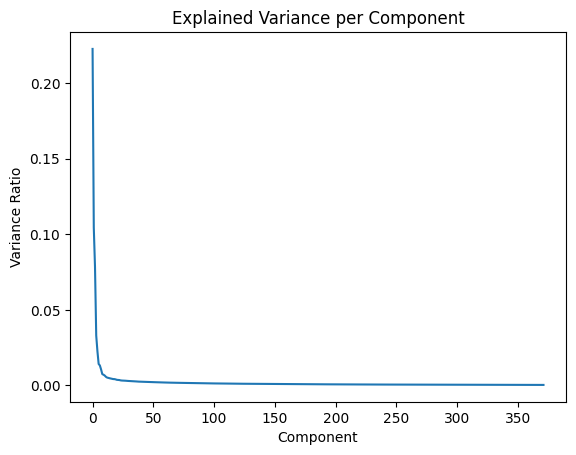

Total variance retained: 0.90012896


In [297]:
plt.plot(X_pca.explained_variance_ratio_)
plt.title("Explained Variance per Component")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

print("Total variance retained:", np.sum(X_pca.explained_variance_ratio_))



In [298]:
# Here we put a threshold to find number of component that preserve our most of variance, threshold was 90% where we 372 component.
# Though we decrease our feature size from 128*128 = 16384 to 372 we still have change of overfitting here.

In [299]:
# getting labels list
Y = []
for d in train:
    Y.append(d["label"])

In [300]:
len(Y)

4096

In [301]:
model = LogisticRegression(max_iter=1000)

In [302]:
X_train_val_pca = X_pca.transform(X)
model.fit(X_train_pca,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [303]:
pred_y = model.predict(X_train_val_pca)

In [304]:
print("Accuracy:", accuracy_score(Y, pred_y))
print(classification_report(Y, pred_y))

Accuracy: 0.87255859375
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       579
           1       1.00      1.00      1.00        43
           2       0.87      0.90      0.89      2044
           3       0.84      0.81      0.83      1430

    accuracy                           0.87      4096
   macro avg       0.91      0.91      0.91      4096
weighted avg       0.87      0.87      0.87      4096



In [305]:
# using validation dataset to test on model that we train on training dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [306]:
val_data = dataset["valid"]
len(val_data)

1024

In [307]:
val_X = []
val_Y = []

In [308]:
for d in val_data:
    val_X.append(d["image"])
    val_Y.append(d["label"])

In [309]:
len(val_X) == len(val_Y)
# so val_X contains images so need to change it numpy array
val_X = np.array(val_X,dtype=np.float32)

In [310]:
# same in train dataset validation dataset also have 128X128 value so we need to flatten that and normalizate it.


In [311]:
# normalizing the value of val_X
val_X = val_X.reshape(val_X.shape[0],-1)
val_X = val_X/255.0

In [312]:
# fitting val_X in pca
val_X_pca = X_pca.transform(val_X)

In [313]:
val_y_predict = model.predict(val_X_pca)

In [314]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_predict))
print(classification_report(val_Y, val_y_predict))

Accuracy value for Validation dataset 0.7880859375
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       145
           1       1.00      1.00      1.00         6
           2       0.83      0.82      0.82       522
           3       0.74      0.74      0.74       351

    accuracy                           0.79      1024
   macro avg       0.83      0.84      0.83      1024
weighted avg       0.79      0.79      0.79      1024



In [315]:
# As accuracy result on validation is lower than what we got in training dataset which was around 0.87 > 0.78
# second thing is with class 1 with only 6 data of class 1, we are getting precision call,recall and f1-score 1. That means we have
# overfitting on model.

In [316]:
# Next step is to use class_weight = "balanced" during our logistic regression in with training set retrain the model and check with
# validation dataset again

In [317]:
balance_model = LogisticRegression(max_iter=1000,class_weight="balanced")

In [318]:
balance_model.fit(X_train_val_pca,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [319]:
val_y_bal_predict = balance_model.predict(val_X_pca)

In [320]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_bal_predict))
print(classification_report(val_Y, val_y_bal_predict))

Accuracy value for Validation dataset 0.765625
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       145
           1       1.00      1.00      1.00         6
           2       0.84      0.76      0.80       522
           3       0.71      0.74      0.72       351

    accuracy                           0.77      1024
   macro avg       0.81      0.84      0.82      1024
weighted avg       0.77      0.77      0.77      1024



In [321]:
# after balanced f1 score for class 0 is decreased from 0.78 to 0.76 but recall is increased from 0.80 to 0.85 where for class 1 remain same
# and class 2 recall is dropped as trade-off with accuracy decrease from 0.78 to 0.77

In [322]:
# lets augment data with train data, see how well does model works

In [323]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

size = (128, 128)
channel = RGB


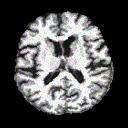

In [324]:
aug = dataset["aug"]
# checking dimension and channels of images in aug
first_aug_image = aug[0]["image"]

print(f"size = {first_aug_image.size}")
print(f"channel = {first_aug_image.mode}")
first_aug_image

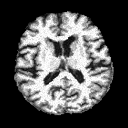

In [325]:
aug_X = []
aug_Y = []


for au in aug:
    img_rgb = au["image"]
    # converting into grayscale image as we found that image that are in aug is RGB
    img_gray = au["image"].convert("L")
    aug_X.append(img_gray)
    aug_Y.append(au["label"])

aug_X[0]


In [373]:
# changing into numpy array
aug_X = np.array(aug_X,dtype=np.float32)
# flatten aug_X array to 1D 
aug_X = aug_X/255.0
aug_X = aug_X.reshape(aug_X.shape[0],-1)
print("Train distribution:", Counter(train_aug_Y))

Train distribution: Counter({np.int64(2): 4088, np.int64(3): 2860, np.int64(0): 1158, np.int64(1): 86})


In [362]:
train_aug_X = np.concatenate([X,aug_X])

In [363]:
train_aug_Y = np.concatenate([Y,aug_Y])

In [379]:
new_pca = PCA(n_components=100)
train_aug_pca = new_pca.fit_transform(train_aug_X)

In [392]:
model_train_aug = LogisticRegression(max_iter=5000)


In [393]:
model_train_aug.fit(train_aug_pca,train_aug_Y)

# new val X pca
new_val_pca = new_pca.transform(val_X)

In [394]:
val_y_bal_predict_2 = model_train_aug.predict(new_val_pca)

In [395]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_bal_predict_2))
print(classification_report(val_Y, val_y_bal_predict_2))

Accuracy value for Validation dataset 0.658203125
              precision    recall  f1-score   support

           0       0.55      0.41      0.47       145
           1       1.00      1.00      1.00         6
           2       0.73      0.77      0.75       522
           3       0.58      0.59      0.58       351

    accuracy                           0.66      1024
   macro avg       0.71      0.69      0.70      1024
weighted avg       0.65      0.66      0.65      1024



In [404]:
# before doing regularization we do scaling data
scaler = StandardScaler()
train_pca_scaled = scaler.fit_transform(train_aug_pca)
val_pca_scaled = scaler.transform(new_val_pca)



In [409]:
# as after adding augmentation data, the accuracy decrease to 0.65 so we are going to add regularization

results = []

for c in [0.01, 0.1, 1, 10,100]:
    reg_model = LogisticRegression(
        C=c,
        max_iter=5000,

    )
    reg_model.fit(train_pca_scaled, train_aug_Y)
    val_pred_1 = reg_model.predict(val_pca_scaled)
    acc = accuracy_score(val_Y, val_pred_1)
    f1 = f1_score(val_Y, val_pred_1, average="macro")
    
    results.append((c, acc, f1))
    
    print(f"C = {c}")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("-" * 40)



C = 0.01
Accuracy: 0.65234375
Macro F1: 0.5109771814520863
----------------------------------------
C = 0.1
Accuracy: 0.654296875
Macro F1: 0.6947073923590219
----------------------------------------
C = 1
Accuracy: 0.6572265625
Macro F1: 0.6985623763412259
----------------------------------------
C = 10
Accuracy: 0.6591796875
Macro F1: 0.7009185243276075
----------------------------------------
C = 100
Accuracy: 0.658203125
Macro F1: 0.6992080070597729
----------------------------------------


In [410]:
# working with test data
dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [411]:
test = dataset["test"]

In [ ]:
test_X = []
test_Y = []

for i_t in test:
    test_